**This is the code to perform five data augmentations on the partwhole dataset in YOLO format**

Augmentations: 90, 180 and 270 degree rotations; horizontal and vertical flipping

In [1]:
import os
import yaml
import cv2
import glob
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
subset = 'train'

# Paths
dataset_path = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v5/"
yaml_file = os.path.join(dataset_path, 'data.yaml') # "/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/data.yaml"
images_dir = os.path.join(dataset_path, subset, 'images') # r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/images"
yolo_labels_dir = os.path.join(dataset_path, subset, 'labels') # r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/labels"

In [3]:
images = os.listdir(images_dir)
yolo_labels = os.listdir(yolo_labels_dir)

# Load class names from YAML
with open(yaml_file, "r") as f:
    data = yaml.safe_load(f)
class_names = data["names"]
print("class names:", class_names)

class names: ['abdomen', 'head', 'thorax']


In [4]:
# Necessary functions
def rotate_point(x, y, angle):
    if angle == 90:
        return 1- y, x
    elif angle == 180:
        return 1 - x, 1 - y
    elif angle == 270:
        return y, 1 - x
    else:
        return x, y

def flip_point(x, y, flip_type):
    if flip_type == 'h':  # horizontal
        return 1 - x, y
    elif flip_type == 'v':  # vertical
        return x, 1 - y
    else:
        return x, y

def load_polygons(label_path):
    polys = []
    with open(label_path, "r") as f:
        for line in f.readlines():
            vals = line.strip().split()
            cls = int(vals[0])
            coords = list(map(float, vals[1:]))
            poly = [(coords[i], coords[i+1]) for i in range(0, len(coords), 2)]
            polys.append((cls, poly))
    return polys

def apply_transform(img, polys, transform):
    """Apply image + polygon transform."""
    if transform == "rot90":
        img_t = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
        new_polys = [(cls, [rotate_point(x, y, 90) for x, y in poly]) for cls, poly in polys]
    elif transform == "rot180":
        img_t = cv2.rotate(img, cv2.ROTATE_180)
        new_polys = [(cls, [rotate_point(x, y, 180) for x, y in poly]) for cls, poly in polys]
    elif transform == "rot270":
        img_t = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
        new_polys = [(cls, [rotate_point(x, y, 270) for x, y in poly]) for cls, poly in polys]
    elif transform == "flip_h":
        img_t = cv2.flip(img, 1)
        new_polys = [(cls, [flip_point(x, y, "h") for x, y in poly]) for cls, poly in polys]
    elif transform == "flip_v":
        img_t = cv2.flip(img, 0)
        new_polys = [(cls, [flip_point(x, y, "v") for x, y in poly]) for cls, poly in polys]
    else:
        img_t = img.copy()
        new_polys = polys
    return img_t, new_polys

def plot_polygons(img, polys, ax, title=""):
    h, w = img.shape[:2]
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    for cls, poly in polys:
        xs = [p[0]*w for p in poly]
        ys = [p[1]*h for p in poly]
        ax.plot(xs + [xs[0]], ys + [ys[0]], linewidth=2)
        ax.text(xs[0], ys[0], class_names[cls], color="yellow", fontsize=8, backgroundcolor="black")
    ax.set_title(title)
    ax.axis("off")

def visualize_augmentations(image_path, label_path):
    img = cv2.imread(image_path)
    polys = load_polygons(label_path)

    transforms = [
        ("original", None),
        ("rot90", "rot90"),
        ("rot180", "rot180"),
        ("rot270", "rot270"),
        ("flip_h", "flip_h"),
        ("flip_v", "flip_v"),
    ]

    fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    for ax, (title, tf) in zip(axs.ravel(), transforms):
        if tf is None:
            img_t, polys_t = img, polys
        else:
            img_t, polys_t = apply_transform(img, polys, tf)
        # plot_yolo_polygon(img_t, polys_t, ax, title)
        plot_polygons(img_t, polys_t, ax, title)

    plt.tight_layout()
    plt.show()

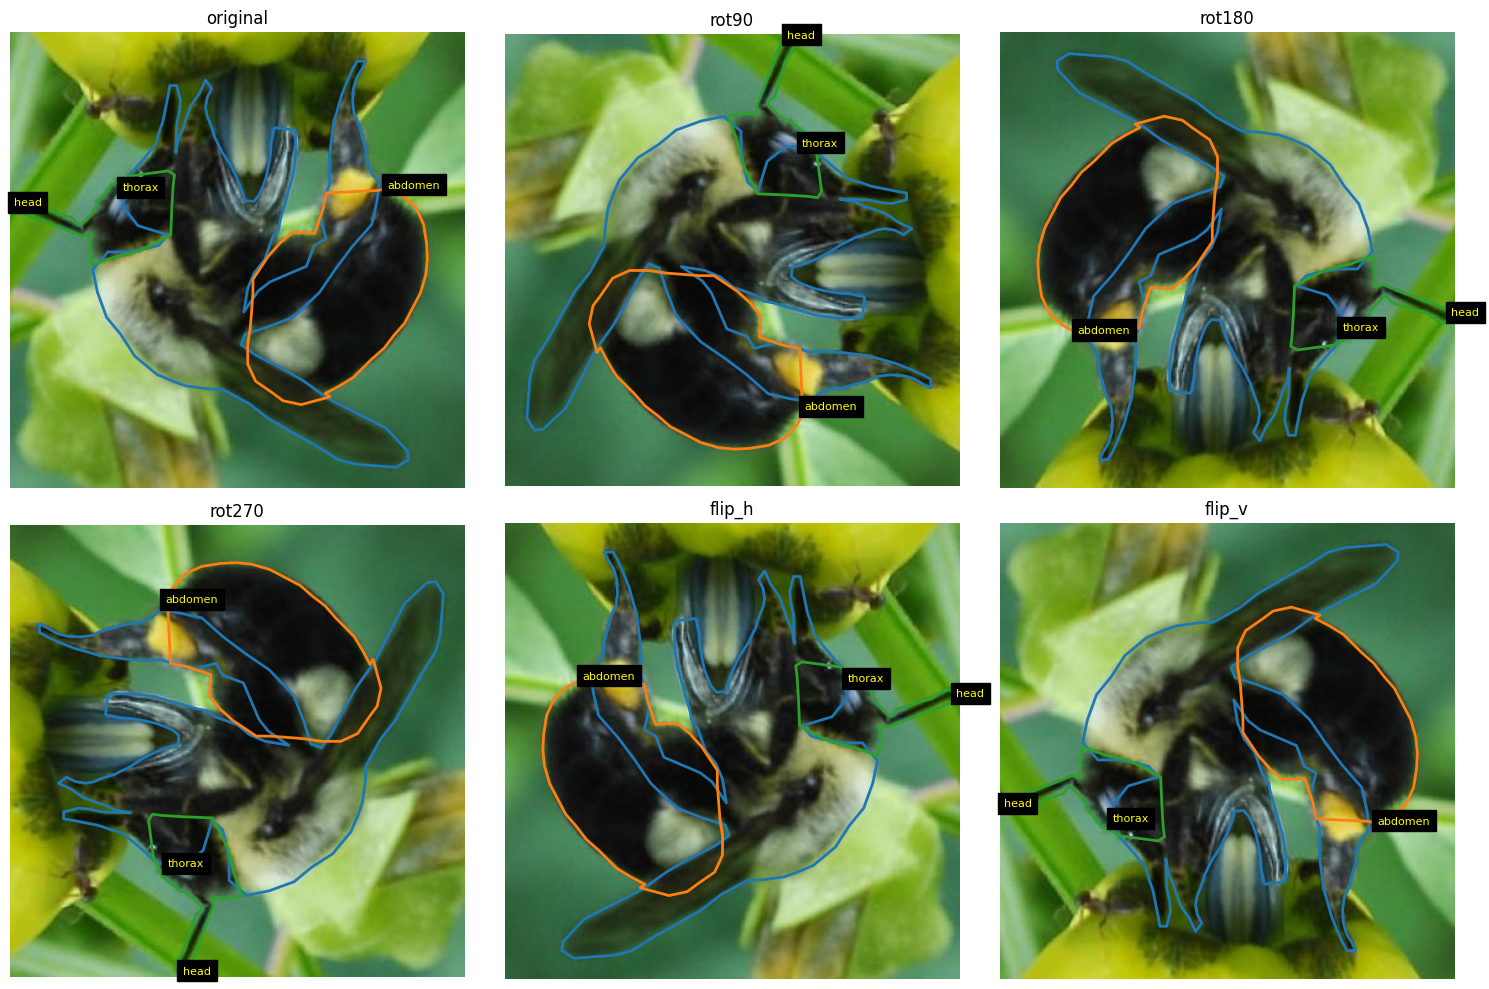

In [5]:
# Get an image and its label
image_file = images[5]
label_file = os.path.splitext(image_file)[0] + ".txt"

# Get the image and label paths
image_path = os.path.join(images_dir, image_file)
label_path = os.path.join(yolo_labels_dir, label_file)

# Visualize augmentations for a single image
visualize_augmentations(image_path, label_path)

In [6]:
# Functions for making the augmented dataset
def save_polygons(label_path, polys):
    with open(label_path, "w") as f:
        for cls, poly in polys:
            coords = " ".join([f"{x:.6f} {y:.6f}" for x, y in poly])
            f.write(f"{cls} {coords}\n")

def augment_dataset(in_dir, img_ext=".jpg"):
    # Batch augment all images + labels in a YOLO segmentation dataset
    img_dir = os.path.join(in_dir, "images")
    label_dir = os.path.join(in_dir, "labels")
    out_img_dir = os.path.join(in_dir, "aug_images")
    out_label_dir = os.path.join(in_dir, "aug_labels")
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_label_dir, exist_ok=True)

    img_paths = glob.glob(os.path.join(img_dir, f"*{img_ext}"))
    print(f"Found {len(img_paths)} images")

    transforms = [
        ("orig", None),
        ("rot90", "rot90"),
        ("rot180", "rot180"),
        ("rot270", "rot270"),
        ("flip_h", "flip_h"),
        ("flip_v", "flip_v"),
    ]

    for img_path in tqdm(img_paths):
        base = os.path.basename(img_path)
        name, ext = os.path.splitext(base)
        label_path = os.path.join(label_dir, name + ".txt")

        if not os.path.exists(label_path):
            print(f"⚠️ Exiting {base} (no label file)")
            return None

        # Load original
        img = cv2.imread(img_path)
        polys = load_polygons(label_path)

        for suffix, tf in transforms:
            if tf is None:
                img_t, polys_t = img, polys
            else:
                img_t, polys_t = apply_transform(img, polys, tf)

            out_img = os.path.join(out_img_dir, f"{name}_{suffix}{ext}")
            out_lbl = os.path.join(out_label_dir, f"{name}_{suffix}.txt")

            cv2.imwrite(out_img, img_t)
            save_polygons(out_lbl, polys_t)

    print(f"✅ Augmentation complete. Saved results in {out_img_dir} and {out_label_dir}. Total expected files: {len(img_paths)} x {len(transforms)} = {len(img_paths)*len(transforms)}")

In [7]:
input_dir = os.path.join(dataset_path, subset)
augment_dataset(in_dir=input_dir)

Found 5787 images


  0%|          | 3/5787 [00:00<09:57,  9.68it/s]

100%|██████████| 5787/5787 [09:03<00:00, 10.65it/s]

✅ Augmentation complete. Saved results in /home/c/choton/beemachine/datasets/Beemachine_Partwhole_v5/train/aug_images and /home/c/choton/beemachine/datasets/Beemachine_Partwhole_v5/train/aug_labels. Total expected files: 5787 x 6 = 34722
